## Comparing populations: Kinh Vietnamese, Chinese South, African in USA, Finland, Japanese 


In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from os.path import join
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [3]:
from mylib import genomes

In [4]:
root_dir = join(Path.home(),"projects/cp_als/second_pair/populations/output/CD")

In [5]:
def one_population(population_name:str,genomes):
    infile = join(root_dir,f"{population_name}/all.csv")
    df = pd.read_csv(infile)
    df = df[genomes[population_name] + ["gene"]]
    sdf = df.groupby(["gene"]).sum()
    tdf = sdf.transpose()
    return tdf

In [6]:
khv= one_population(population_name="KHV",genomes=genomes)
chb= one_population(population_name="CHB",genomes=genomes)
gbr= one_population(population_name="GBR",genomes=genomes)
fin= one_population(population_name="FIN",genomes=genomes)
asw= one_population(population_name="ASW",genomes=genomes)
jpt= one_population(population_name="JPT",genomes=genomes)
clm = one_population(population_name="CLM",genomes=genomes)
chs = one_population(population_name="CHS",genomes=genomes)
cdx = one_population(population_name="CDX",genomes=genomes)
gih = one_population(population_name="GIH",genomes=genomes)
itu = one_population(population_name="ITU",genomes=genomes)
stu = one_population(population_name="STU",genomes=genomes)
mxl = one_population(population_name="MXL",genomes=genomes)
pur = one_population(population_name="PUR",genomes=genomes)
pjl = one_population(population_name="PJL",genomes=genomes)
beb = one_population(population_name="BEB",genomes=genomes)
acb = one_population(population_name="ACB",genomes=genomes)
esn = one_population(population_name="ESN",genomes=genomes)
gwd = one_population(population_name="GWD",genomes=genomes)
lwk = one_population(population_name="LWK",genomes=genomes)
msl = one_population(population_name="MSL",genomes=genomes)
yri = one_population(population_name="YRI",genomes=genomes)

In [7]:
df=pd.concat([esn,khv,chs,fin,jpt])

In [8]:
df

gene,ABCB1,ATG16L1,ATG4C,CARD9,CDKAL1,DLG5,GPR35,HLA-DRB1,IL10,IL10RA,...,NOD2,PTPN2,PTPN22,SLC22A4,SLC22A5,STAT3,TLR4,TNF,TNFSF15,ZMIZ1
HG03136,161,53,161,2,1166,179,38,0,11,21,...,34,112,54,56,21,59,35,0,13,307
HG03193,241,18,118,0,1207,202,43,0,1,18,...,36,152,51,59,48,58,43,1,16,349
HG03343,233,89,16,6,1110,191,51,0,1,33,...,32,96,33,57,4,56,37,1,27,359
HG02973,126,75,116,9,1223,266,33,6,10,34,...,41,133,48,59,22,91,27,2,18,417
HG03105,213,51,149,7,942,248,45,0,11,20,...,51,133,51,54,15,95,44,0,18,325
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
NA19086,86,49,13,1,1117,277,67,7,3,28,...,2,114,38,74,70,22,14,1,14,378
NA19085,99,38,8,13,977,193,69,0,6,28,...,3,83,63,73,57,93,32,0,14,401
NA19001,189,45,96,1,1078,146,54,20,2,14,...,36,127,49,54,48,92,15,0,15,332
NA18954,62,60,99,15,826,145,58,0,5,28,...,29,79,2,55,47,21,17,0,13,418


In [9]:
df = df.drop(columns=["NOD2", "IL23R", "ATG16L1", "STAT3"], errors="ignore")
df.shape

(512, 25)

In [10]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

In [11]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

In [12]:
df['PC1'] = X_pca[:,0]
df['PC2'] = X_pca[:,1]

In [13]:
df.shape

(512, 27)

In [14]:
target_population = "khv"

In [17]:
import os
import matplotlib.pyplot as plt

def save_pca_first_two_components_pdf(
    df,
    genomes,
    target_population="KHV",
    out_dir="plots",
    filename=None,
    #figsize=(2.6, 2.4),  # sized for 3 subfigures across full-width figure
    figsize=(6, 4), 
):
    # Publication-friendly PDF font embedding
    plt.rcParams["pdf.fonttype"] = 42
    plt.rcParams["ps.fonttype"] = 42

    fig, ax = plt.subplots(figsize=figsize)
    fig.patch.set_facecolor("white")
    ax.set_facecolor("white")

    colors = {
        "ESN": "#E41A1C",  # red
        "KHV": "#1F4E79",  # dark blue
        "JPT": "#4292C6",  # lighter blue
        "FIN": "#F39C12"   # orange
    }

    marker_size = 5

    ax.scatter(
        df.loc[genomes["ESN"], "PC1"],
        df.loc[genomes["ESN"], "PC2"],
        c=colors["ESN"],
        alpha=0.85,
        edgecolor="black",
        linewidth=0.4,
        s=marker_size,
        label="Esan in Nigeria",
        marker="o"
    )

    ax.scatter(
        df.loc[genomes["KHV"], "PC1"],
        df.loc[genomes["KHV"], "PC2"],
        c=colors["KHV"],
        edgecolor="black",
        linewidth=0.4,
        s=marker_size,
        label="Kinh in Vietnam",
        marker="s"
    )

    ax.scatter(
        df.loc[genomes["JPT"], "PC1"],
        df.loc[genomes["JPT"], "PC2"],
        c=colors["JPT"],
        facecolors="none",        # hollow marker
        edgecolor="#4292C6",      # blue edge
        linewidth=0.9,
        marker="s",
        alpha=0.85,
        s=marker_size,
        label="Japanese in Japan",
    )

    ax.scatter(
        df.loc[genomes["FIN"], "PC1"],
        df.loc[genomes["FIN"], "PC2"],
        c=colors["FIN"],
        alpha=0.85,
        edgecolor="black",
        linewidth=0.4,
        s=marker_size,
        label="Finnish in Finland",
        marker="D"
    )

    ax.set_xlabel("Principal Component 1", fontsize=7)
    ax.set_ylabel("Principal Component 2", fontsize=7)
    ax.tick_params(axis="both", labelsize=6)
    ax.grid(True, alpha=0.25)

    ax.legend(
        loc="lower right",
        frameon=True,
        fontsize=5.5,
        handlelength=0.8,
        borderpad=0.2,
        labelspacing=0.2,
        handletextpad=0.3
    )

    plt.tight_layout()

    # os.makedirs(out_dir, exist_ok=True)
    # if filename is None:
    #     filename = f"{target_population.lower()}_pca_first_two_components.pdf"
    # output_file = os.path.join(out_dir, filename)

    # plt.savefig(
    #     output_file,
    #     format="pdf",
    #     bbox_inches="tight",
    #     facecolor="white"
    # )
    # plt.close()

    # print(f"Saved: {output_file}")
    # return output_file
    plt.show()

/var/folders/mk/qv7kjtr17ls_fqfn64hdptt00000gn/T/ipykernel_26721/3830063183.py:53: UserWarning: You passed both c and facecolor/facecolors for the markers. c has precedence over facecolor/facecolors. This behavior may change in the future.
  ax.scatter(


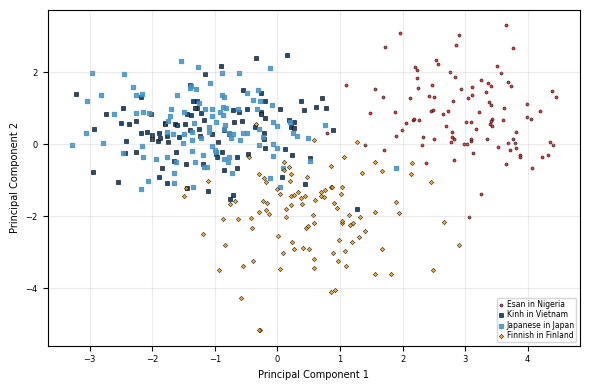

In [18]:
save_pca_first_two_components_pdf(
    df=df,
    genomes=genomes,
    target_population="KHV",
    out_dir="plots",
    filename="khv_pca_first_two_components.pdf"
)